In [19]:
import numpy as np
import matplotlib.pyplot as plt

SNR:  0.0551348058624767
SNR:  3.731468165268605


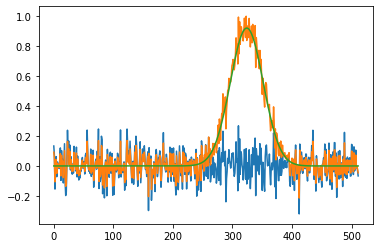

In [20]:
import random
def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU
relu1 = get_ReLU(0.2)
relu2 = get_ReLU(0.3)

min_val = 20
max_val = 480
target_snr = 5
mu1 = random.randint(min_val,max_val)
sigma1 = random.randint(10,30)
mu2 = random.randint(min_val,max_val)
sigma2 = random.randint(10,30)
rng = np.random.default_rng()
weight1 = relu1(rng.random())
weight2 = relu2(rng.random())
pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

mu, sigma = 0, 0.1 # mean and standard deviation
s = np.random.normal(mu, sigma, 512)
a = np.linspace(0,500,512)
wave = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
snr = max(wave)/max(s)
print("SNR: ", max(wave)/max(s))
weight = target_snr/snr
res = wave*weight + s
clean = wave*weight
normalization_constant =  max(max(res),max(clean))
res = res/normalization_constant
clean = wave*weight/normalization_constant
print("SNR: ", max(res)/max(s))
plt.plot(s)
plt.plot(res)
plt.plot(clean)

In [21]:
# Source - https://stackoverflow.com/a/63177397
# Posted by JuliettVictor, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-09, License - CC BY-SA 4.0

def signaltonoise(a, axis=0, ddof=0):
    a = np.asanyarray(a)
    m = a.mean(axis)
    sd = a.std(axis=axis, ddof=ddof)
    return np.where(sd == 0, 0, m/sd)


signaltonoise(res)

array(0.47541173)

In [22]:
import os
try:
    os.chdir("/home/maniacalm/bin/VQVAE_studies")
except FileNotFoundError:
    print("Either filepath is wrong or this is ran on another computer")

In [23]:
import numpy as np
import matplotlib.pyplot as plt

a=np.load("snb-Z-signal-0.npy",allow_pickle=True)
c=np.load("snb-Z-clnsig-0.npy",allow_pickle=True)
nwf=a.size
ntcks=len(a[0])-54
train_noise = []
train_signal = []
for j in range(nwf-50):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    train_noise.append(ya)
    train_signal.append(yc)
test_noise = []
test_signal = []
for j in range(nwf-50,nwf-1):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    test_noise.append(ya)
    test_signal.append(yc)
train_noise_c = np.reshape(np.array(train_noise), (-1, 1,512))
train_signal_c = np.reshape(np.array(train_signal), (-1, 1,512))
test_noise_c = np.reshape(np.array(test_noise), (-1, 1,512))
test_signal_c = np.reshape(np.array(test_signal), (-1, 1,512))
print(len(train_noise_c))
print(train_noise_c.shape)

196
(196, 1, 512)


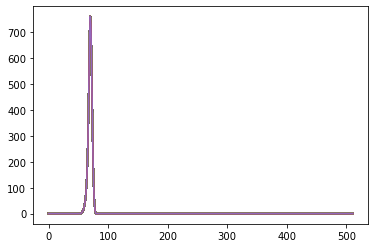

In [24]:

for i in range(len(train_signal)-1):
    plt.plot(train_signal[i])

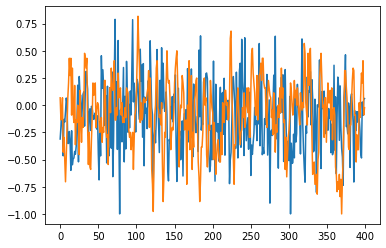

In [25]:
def normalization(s):
    s = np.array(s)
    return s/max(abs(s))

i = 0
mu = -0.08
sigma = 0.32
dat = normalization(np.random.normal(mu, sigma, 400))
dat1 = normalization(train_noise[i][100:500])
plt.plot(dat)
plt.plot(dat1)

In [26]:
from scipy import stats
# Generating some data
np.random.seed(10)  # for repeatability

mu_true = mu   # true peak position 
sigma_true = sigma # true standard deviation 
M = 400 # number of measurements
D = dat1#np.random.normal(mu_true, sigma_true, M)#stats.norm.rvs(mu_true, sigma_true, size=M) | # M measurements (samples)
# Estimators: sample mean and (sqrt of) sample variance
# Sometimes the *unbiased* estimator for the sample variance is used 
# with (M-1) degrees of freedom...
mu_est = D.sum()/M
sigma_est = np.sqrt(((D-mu_est)**2).sum()/M)
print("""
      (mu,sigma)_true = {0:.2f}, {1:.2f}
      
      Sample estimators: 
      (mu,sigma)_0  = {2:.2f}, {3:.2f} (based on {4} measurements)
      """.format(mu_true, sigma_true, mu_est, sigma_est, M))


      (mu,sigma)_true = -0.08, 0.32
      
      Sample estimators: 
      (mu,sigma)_0  = -0.08, 0.32 (based on 400 measurements)
      


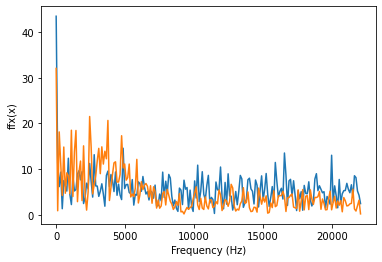

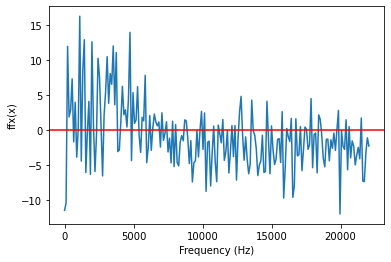

In [27]:
from numpy.fft import rfft,irfft,rfftfreq

dat_fft = rfft(dat)
N=len(dat)
freq_dat = rfftfreq(N, d=1/44100)
plt.plot(freq_dat,np.abs(dat_fft))

dat1_fft = rfft(dat1)
N=len(dat1)
freq_dat = rfftfreq(N, d=1/44100)
plt.plot(freq_dat,np.abs(dat1_fft))

# mu = 1
# sigma = 2500
# gauss = get_gaussian(mu,sigma)
# a = np.linspace(0,20000,20000)
# plt.plot(gauss(a)/max(gauss(a)))
plt.xlabel("Frequency (Hz)")
plt.ylabel("ffx(x)")
plt.show()
plt.plot(freq_dat,np.abs(dat1_fft)-np.abs(dat_fft))
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel("Frequency (Hz)")
plt.ylabel("ffx(x)")
plt.show()

Text(0, 0.5, 'Power')

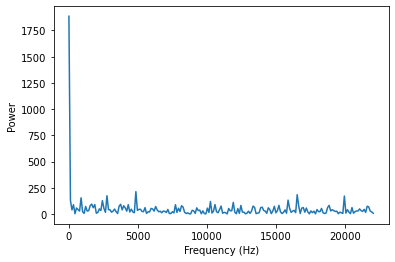

In [28]:
power = np.abs(dat_fft)**2
plt.plot(freq_dat, power)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")

Text(0, 0.5, 'Phase (radians)')

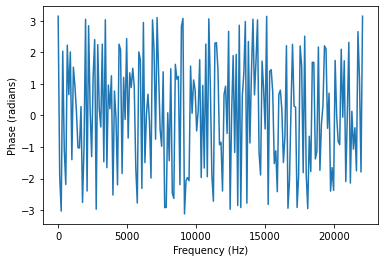

In [29]:
plt.plot(freq_dat, np.angle(dat_fft))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")